In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("YOUR_PATH_HERE")

print(df.head())

print(df.shape)

print(df.info())

   match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
0   1741000          1                      40                       23   
1  30579330          0                      44                       33   
2  38972692          0                      25                       27   
3  38763513          1                      36                       37   
4  39506973          1                      49                       13   

   team0_team_total_networth  team0_team_total_damage  \
0                     141415                    92902   
1                     131636                    98973   
2                     120000                    64990   
3                     146246                   102620   
4                     164230                   103525   

   team0_team_total_objectivedamage  team0_team_avg_level  \
0                             24814             20.166667   
1                             11407             24.833333   
2                      

# Inspecting Missing Values and Data/Features Distributions

In [3]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Series([], dtype: int64)


In [4]:
print(df["team0_won"].value_counts())

print(df["team0_won"].value_counts(normalize=True))

team0_won
1    8899
0    8803
Name: count, dtype: int64
team0_won
1    0.502712
0    0.497288
Name: proportion, dtype: float64


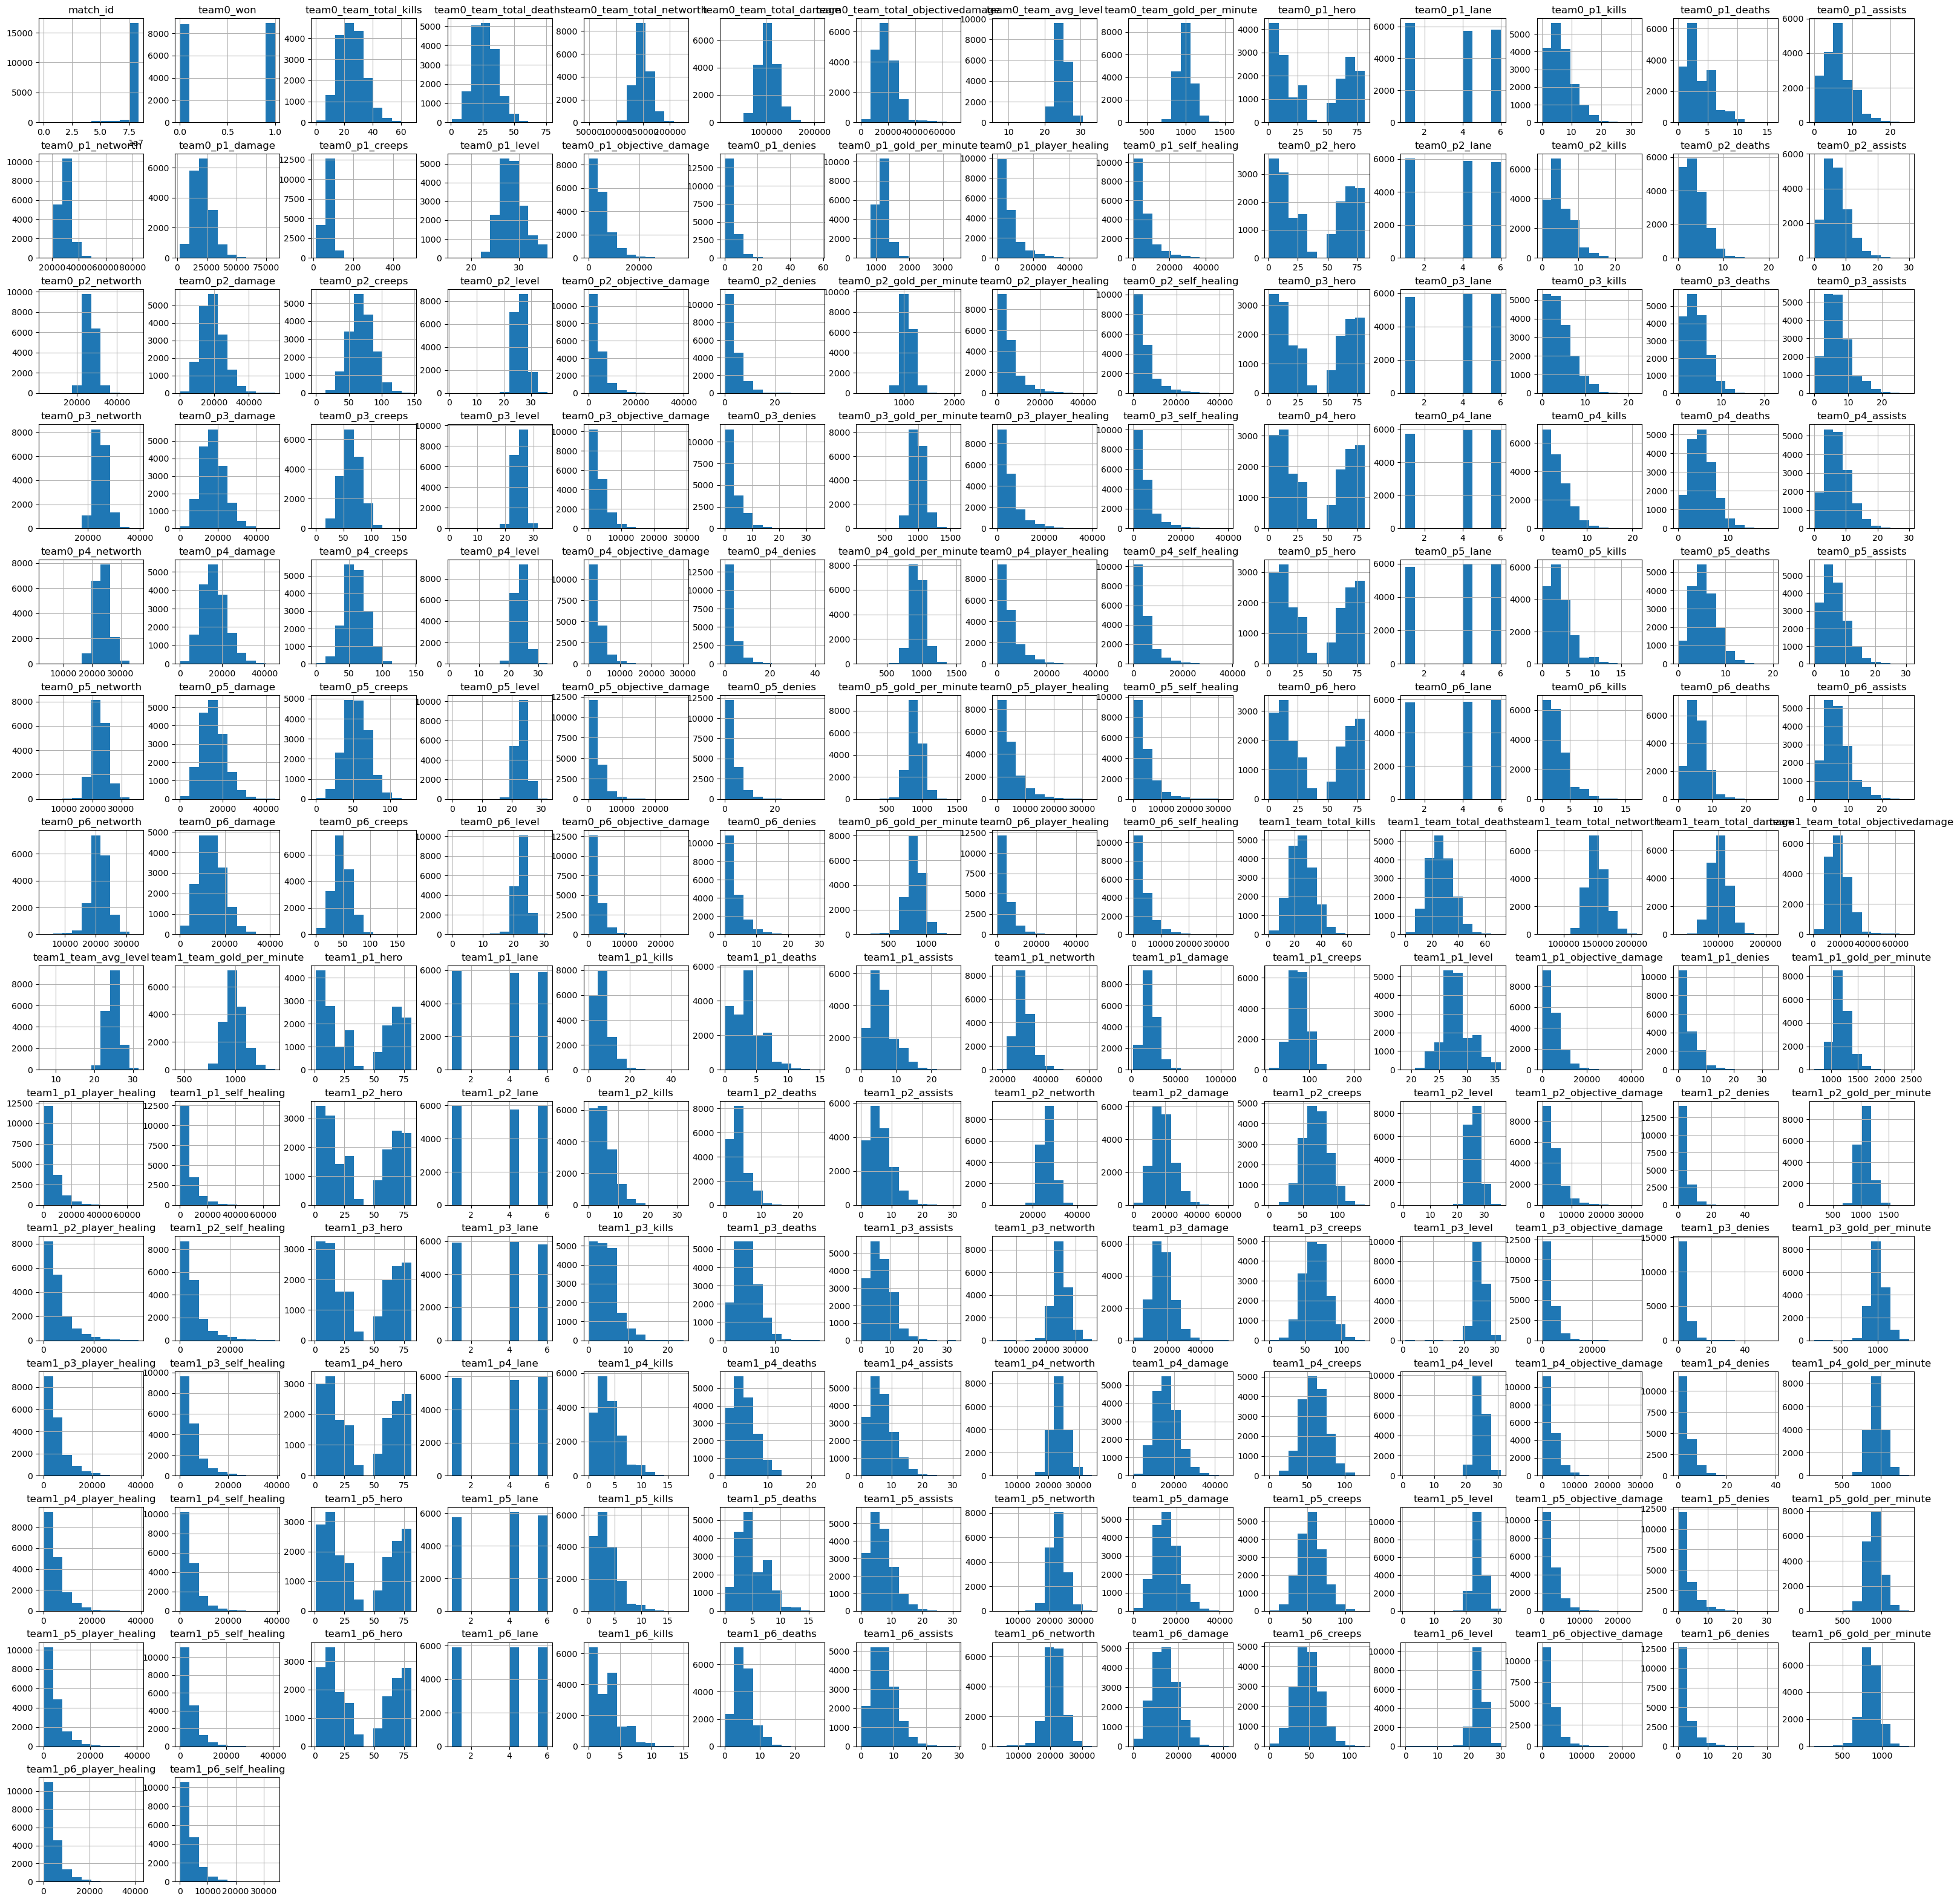

In [5]:
df.hist(figsize=(40, 40))

plt.show()

# Removing Outliers

count     17702.000000
mean     148685.716021
std       14469.524160
min       47982.000000
25%      138942.500000
50%      147661.000000
75%      157441.500000
max      225352.000000
Name: team0_team_total_networth, dtype: float64


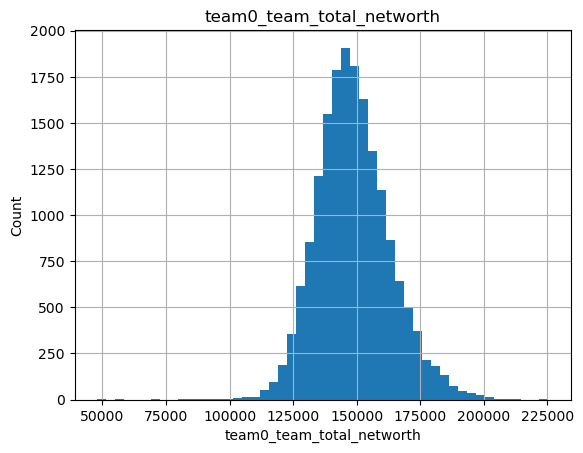

In [6]:
feature = "team0_team_total_networth"

print(df[feature].describe())

df[feature].hist(bins=50)

plt.title(feature)

plt.xlabel(feature)

plt.ylabel("Count")

plt.show()

In [8]:
threshold = 75000

count = (df["team0_team_total_networth"] < threshold).sum()

print(count)

outliers = df[df["team0_team_total_networth"] < 75000]

print((outliers.head(20)))

4
       match_id  team0_won  team0_team_total_kills  team0_team_total_deaths  \
334    54195208          0                       0                       18   
2425   80881803          0                      10                       14   
13353  82959638          1                       4                        4   
16905  83239773          0                       6                        6   

       team0_team_total_networth  team0_team_total_damage  \
334                        58350                    12725   
2425                       47982                    26242   
13353                      70430                    31761   
16905                      57316                    21638   

       team0_team_total_objectivedamage  team0_team_avg_level  \
334                               11430             10.000000   
2425                               7065              9.833333   
13353                             22196              6.833333   
16905                              5

# Inspecting Correlations

In [9]:
corr = df.corr(numeric_only=True)

print(corr["team0_won"].sort_values(ascending=False))

team0_won                           1.000000
team0_team_total_networth           0.427628
team0_team_gold_per_minute          0.427345
team0_team_total_objectivedamage    0.389129
team0_team_total_kills              0.388675
                                      ...   
team1_team_avg_level               -0.370631
team1_team_total_objectivedamage   -0.376764
team1_team_total_kills             -0.378046
team1_team_gold_per_minute         -0.412264
team1_team_total_networth          -0.412339
Name: team0_won, Length: 184, dtype: float64
